# 🛰️ Summer School: Deploying Neural Networks on FPGAs for Satellites

In this session we will walk through the process of deploying a neural network onto the FPGA VectorBlox simulator, using VectorBlox's prepared soft-core architecture.

## 📚 Learning Objectives

- Get familiar with the prepared neural network for coronal hole segmentation on the Sun
- Understand the metrics used to evaluate the network
- Understand the process of deploying a neural network onto an FPGA from a high level
- Understand the need and importance of the individual steps, such as quantization
- Compare individual deployments and analyze the results

## 🛠️ Tools and Libraries

Throughout this notebook we will use the following tools to move a model onto the accelerator:

- **VectorBlox SDK**: vnnx_compile turns an INT8 model into a .vnnx binary, and vbx.sim runs that binary exactly as the chip would, counting cycles
- **TensorFlow / Keras**: the trained floating-point SCSS-Net model, and INT8 quantization
- **TFLite**: the INT8 model format the compiler accepts
- **NumPy & Matplotlib**: for running images through the model and visualizing masks and metrics

## 🚀 What You Will Do
- Meet the model and metrics — the network, the data, and why we score with Dice/IoU.
- Try the float model and watch it fail — the chip is INT8-only.
- Fix the numbers — quantize to INT8.
- Fix the operations — rewrite the graph into hardware-legal ops.
- Compile and run — build the .vnnx and run it in the simulator.
- Deep dives (optional) — quantization cost, latency, bottlenecks, and core sizing.

> 💡 Before you start: pick a plain CPU runtime, not a GPU. The simulator is CPU-only, so a GPU buys you nothing. The setup below takes about 10 minutes the first time; after a kernel restart it is reused in seconds.

In [1]:
# ============================================================================
#  THE ONLY LINE YOU NEED TO EDIT
#  Point this at micro_scss_progress_package on your Google Drive.
# ============================================================================
DRIVE_PKG_DIR = "/content/drive/MyDrive/spacelab/micro_scss_progress_package"
# ============================================================================

## 0. Setup (run once)

This setup will prepare a few things we need before we can actually get on with deploying the neural network to the FPGA simulator.

First, we will download the scss_net_package (along with the models) from Google Drive and save it into the Colab environment. This way we get quick, direct file-system access to the files we need, and we won't have to go over the network every single time.

Next, we need to install and set up the VectorBlox FPGA simulator. This is usually software that gets installed once on your computer, with a separate Python package used as the interface to operate the system package. Since we are in the Colab environment, we need a few tricks to set the environment up properly. Hopefully all you'll need to do is run the cell — fingers crossed!

> ℹ️ The whole process should take roughly 10 minutes, most of which is the VectorBlox SDK install and setup.

Following cells will try to access the scss_net package from google drive and download relevant files (models, scripts, and sample data) in the colab environment.

### Copying the Data to Local Disk

Here, we copy the data off Google Drive onto the local disk, just once. Drive is mounted over the network, which makes reads noticeably slow. Later in the notebook we'll be timing operations down to the millisecond, and slow Drive reads would drown out the numbers we actually care about. Copying everything locally now keeps those measurements clean.

In [2]:
import os, sys, json, time, struct, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or Path("/content").is_dir()

if IN_COLAB and not Path("/content/drive/MyDrive").is_dir():
    from google.colab import drive
    drive.mount("/content/drive")

PKG_DRIVE = Path(DRIVE_PKG_DIR)
if not PKG_DRIVE.is_dir():
    raise FileNotFoundError(
        "Package not found: " + str(PKG_DRIVE) +
        "\nEdit DRIVE_PKG_DIR in this cell to point at the folder on your Drive."
    )

REQUIRED = [
    "01_models/selected_candidate/256x256_model-4-3.h5",
    "01_models/exported_tflite_vnnx/model-4-3-fp32.tflite",
    "01_models/exported_tflite_vnnx/model-4-3-int8.tflite",
    "01_models/exported_tflite_vnnx/model-4-3-int8-vbx.tflite",
    "01_models/exported_tflite_vnnx/model-4-3_V1000_ncomp.vnnx",
    "03_scripts_micro_pipeline/analyze_model.py",
    "03_scripts_micro_pipeline/analyze_vnnx_simulation.py",
    "04_sample_data/256x256_20_pairs/IMGS",
    "04_sample_data/256x256_20_pairs/MASKS",
]
missing = [r for r in REQUIRED if not (PKG_DRIVE / r).exists()]
if missing:
    raise FileNotFoundError("Missing from the package:\n  " + "\n  ".join(missing))
print("Found the package:", PKG_DRIVE)


Mounted at /content/drive
Found the package: /content/drive/MyDrive/spacelab/micro_scss_progress_package


In [3]:
# Copy the data off Drive onto local disk once. Drive is a network mount, so reads are
# slow, and later we're timing things in milliseconds where that would drown everything out.
WORK = Path("/content/workshop") if IN_COLAB else Path.home() / "workshop_fpga"
WORK.mkdir(parents=True, exist_ok=True)
for sub in ["01_models", "03_scripts_micro_pipeline", "04_sample_data"]:
    dst = WORK / sub
    if not dst.exists():
        shutil.copytree(PKG_DRIVE / sub, dst)

MODELS   = WORK / "01_models"
H5       = MODELS / "selected_candidate" / "256x256_model-4-3.h5"
TFL_FP32 = MODELS / "exported_tflite_vnnx" / "model-4-3-fp32.tflite"
TFL_INT8 = MODELS / "exported_tflite_vnnx" / "model-4-3-int8.tflite"
TFL_VBX  = MODELS / "exported_tflite_vnnx" / "model-4-3-int8-vbx.tflite"
VNNX_PKG = MODELS / "exported_tflite_vnnx" / "model-4-3_V1000_ncomp.vnnx"
SCRIPTS  = WORK / "03_scripts_micro_pipeline"
IMGS     = WORK / "04_sample_data" / "256x256_20_pairs" / "IMGS"
MASKS    = WORK / "04_sample_data" / "256x256_20_pairs" / "MASKS"
print("Working from:", WORK)
print("Images:", len(list(IMGS.glob('*.png'))), "| masks:", len(list(MASKS.glob('*.png'))))

Working from: /content/workshop
Images: 20 | masks: 20


### Cloning the VectorBlox SDK

Here, we clone the VectorBlox SDK and pin it to release-v3.0, so it matches the .vnnx files shipped in the package. Version matters here: a .vnnx binary remembers which SDK built it, and the simulator refuses to load one from a mismatched version.

In [4]:
# Clone the SDK, pinned to release-v3.0 so it matches the .vnnx files in the package.
SDK_TAG = "release-v3.0"
SDK_DIR = Path("/content/VectorBlox-SDK") if IN_COLAB else Path.home() / "VectorBlox-SDK"

if SDK_DIR.exists():
    current = subprocess.run(["git", "-C", str(SDK_DIR), "describe", "--tags", "--always"],
                             capture_output=True, text=True).stdout.strip()
    if SDK_TAG in current:
        print(f"Existing checkout already at {current}")
    elif (SDK_DIR / "setup_vars.sh").exists():
        print(f"Checkout is at {current!r}, need {SDK_TAG}; re-cloning.")
        shutil.rmtree(SDK_DIR)
    else:

        raise RuntimeError(f"{SDK_DIR} exists but is not the VectorBlox SDK.")

if not SDK_DIR.exists():
    !apt-get -qq install -y git-lfs > /dev/null 2>&1
    !git lfs install --skip-repo
    !git clone --depth 1 --branch {SDK_TAG} https://github.com/Microchip-Vectorblox/VectorBlox-SDK.git {SDK_DIR}

!cd {SDK_DIR} && git lfs pull

# The simulator .so lives in Git LFS. If the pull didn't fetch it you get a tiny pointer
# file instead of the real library, which is an easy thing to trip on, so check for it.
CANDIDATE_SO = [
    SDK_DIR / "python" / "vbx" / "vbx" / "sim" / "libvbx_cnn_sim.so",
    SDK_DIR / "lib" / "libvbx_cnn_sim.so",
]
real_so = []
for so in CANDIDATE_SO:
    if not so.exists():
        continue
    if so.open("rb").read(64).startswith(b"version https://git-lfs"):
        print(f"  LFS pointer only: {so.relative_to(SDK_DIR)}")
    else:
        real_so.append(so)
        print(f"  OK: {so.relative_to(SDK_DIR)} ({so.stat().st_size:,} B)")
if not real_so:
    raise RuntimeError("libvbx_cnn_sim.so not fetched; re-run: !cd " + str(SDK_DIR) + " && git lfs pull")
print(f"SDK ready: {SDK_DIR} @ {SDK_TAG}")

Git LFS initialized.
Cloning into '/content/VectorBlox-SDK'...
remote: Enumerating objects: 510, done.
remote: Counting objects: 100% (510/510), done.
remote: Compressing objects: 100% (410/410), done.
remote: Total 510 (delta 118), reused 325 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (510/510), 47.65 MiB | 15.92 MiB/s, done.
Resolving deltas: 100% (118/118), done.
  OK: python/vbx/vbx/sim/libvbx_cnn_sim.so (6,695,456 B)
  OK: lib/libvbx_cnn_sim.so (6,695,456 B)
SDK ready: /content/VectorBlox-SDK @ release-v3.0


Now build the compiler environment. This is the ~10 minute step, and it only runs on a
fresh runtime. If `vbx_env` already exists the cell skips it.

In [5]:
%%bash
set -euo pipefail
cd /content/VectorBlox-SDK
if [ -d vbx_env ]; then
  echo "vbx_env is already built, skipping the ~10 min step."
else
  bash install_dependencies.sh 2>&1 | tail -5
  source setup_vars.sh
  # Safety check: if the venv isn't active, stop now, before pip installs anything into
  # Colab's own Python and breaks it.
  python - <<'PY'
import sys
assert sys.prefix.rstrip("/").endswith("vbx_env"), f"venv NOT active: {sys.prefix}"
print("venv OK:", sys.prefix, "| python", sys.version.split()[0])
PY
fi

  1350K                                                       100%  572G=0.05s

2026-08-25 13:30:45 (24.2 MB/s) - ‘flatc.tar.gz’ saved [1382707/1382707]

flatc
Initial install of VBX Python Environment required. May take several minutes...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 KB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.1/282.1 KB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 38.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 KB 33.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 38.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 72.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.21.0 requires protobuf<=6.32,>=4.21.6; python_version < "3.11", but you have protobuf 3.20.3 which is incompatible.


### Loading the Simulator into the Notebook

With the SDK cloned, we can pull the VectorBlox simulator into our Python session. The simulator is a native library loaded through `ctypes`, which is handy: it doesn't care that Colab runs a newer Python than the compiler does. We set `VBX_SDK` first (the library looks for it on import) and then print the accelerator core sizes this build offers — we'll choose one of these later.


In [6]:
# Import the simulator into this kernel. It's a native .so loaded through ctypes, so it
# doesn't care that Colab runs Python 3.12. VBX_SDK has to be set before the import.
os.environ["VBX_SDK"] = str(SDK_DIR)
os.environ["NX_SDK"]  = str(SDK_DIR / "snp_compiler")
_vbx_py = str(SDK_DIR / "python" / "vbx")
if _vbx_py not in sys.path:
    sys.path.insert(0, _vbx_py)

import numpy as np
import vbx.sim
from vbx.generate.vnnx_types import preset_select, graph_version
print("simulator loaded:", vbx.sim.__file__)
print("core sizes available:", list(preset_select["PRESET"].keys()))

simulator loaded: /content/VectorBlox-SDK/python/vbx/vbx/sim/__init__.py
core sizes available: ['V250', 'V500', 'V1000', 'V2000', 'V4000']


### A Wrapper for the SDK Command-Line Tools

The compiler and its tools live in a separate virtual environment (`vbx_env`, built on its own Python) because they carry heavy, version-pinned dependencies. A `source`-d environment doesn't survive from one Colab cell to the next, so instead of activating it we call each tool as a subprocess pointed straight at `vbx_env`. The `vbx_tool` helper below does exactly that, and we'll reuse it every time we compile or verify a model.

We also add two small helpers for reading the compiler's output. The compiler is noisy — it prints walls of TensorFlow/CUDA banners and will often exit with code 0 even when it actually refused to build. So `clean_log` strips the banners, and `produced_vnnx` judges success the only reliable way: by checking whether a real `.vnnx` binary was actually written.


In [7]:
# The compiler lives in vbx_env (Python 3.10). 'source' doesn't survive between Colab
# cells, so we run the tools as subprocesses against vbx_env/bin instead.
VBX_ENV = SDK_DIR / "vbx_env"
if not (VBX_ENV / "bin" / "python").exists():
    raise RuntimeError("vbx_env missing - run the build cell above.")

def vbx_tool(tool, *args, cwd=None, echo=True, timeout=3600):
    """Run an SDK tool (vnnx_compile, tflite_verify, ...) inside vbx_env. Returns (rc, output)."""
    exe = VBX_ENV / "bin" / tool
    if not exe.exists():
        raise FileNotFoundError(f"{tool} not found in {VBX_ENV/'bin'}")
    env = dict(os.environ)
    env["VBX_SDK"] = str(SDK_DIR)
    env["NX_SDK"] = str(SDK_DIR / "snp_compiler")
    env["PATH"] = f"{VBX_ENV/'bin'}{os.pathsep}{env['PATH']}"
    env["VIRTUAL_ENV"] = str(VBX_ENV)
    env.pop("PYTHONPATH", None)   # don't leak this kernel's sys.path into the subprocess
    env.pop("PYTHONHOME", None)
    cmd = [str(exe)] + [str(a) for a in args]
    if echo:
        print("$", tool, *[str(a) for a in args])
    lines = []
    proc = subprocess.Popen(cmd, cwd=str(cwd) if cwd else None, env=env,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout:
        lines.append(line)
        if echo:
            print("  ", line.rstrip())
    proc.wait(timeout=timeout)
    return proc.returncode, "".join(lines)


# The compiler prints a wall of TensorFlow/CUDA banners and often exits 0 even when it
# refuses. So we judge success by whether a real .vnnx appeared, and strip the banners.
_LOG_NOISE = ("cuda_", "cuDNN", "cuFFT", "cuBLAS", "TF-TRT", "stream_executor", "Unable to register")
def clean_log(text, n=10):
    lines = [l for l in text.splitlines() if l.strip() and not any(k in l for k in _LOG_NOISE)]
    return "\n".join(lines[-n:]) or "(only environment/TensorFlow noise)"
def produced_vnnx(path):
    """A compile truly succeeded only if a real .vnnx binary was written."""
    p = Path(path)
    return p.exists() and p.stat().st_size > 1024

### Checkpoint: Is Everything Ready?

One quick sanity check before we move on. It is much nicer to catch a half-finished setup here than to hit a confusing error three sections later. If both lines below report **OK**, the simulator imported cleanly and the compiler runs — you're good to go. If not, the usual fix is *Runtime → Restart session*, then run Section 0 again from the top.


In [8]:
# Checkpoint. Better to catch a half-broken setup here than three sections later.
ok_sim = False
try:
    import vbx.sim as _s; ok_sim = True
except Exception as e:
    print("SIMULATOR IMPORT FAILED:", e)

rc, _ = vbx_tool("vnnx_compile", "--help", echo=False)
print("simulator import :", "OK" if ok_sim else "FAILED")
print("compiler runs    :", "OK" if rc == 0 else f"FAILED (rc={rc})")
print("\nIf both say OK you're good. If not: Runtime > Restart session, then run Section 0 again.")

simulator import : OK
compiler runs    : OK

If both say OK you're good. If not: Runtime > Restart session, then run Section 0 again.


## Setup Complete — What You Now Have

If the setup ran properly, you should now be able to access the models and scripts from the `scss_net_package`, and have the VectorBlox simulator and compiler ready to use.

You can browse the files from the package directly in Colab: open the **Files** panel on the left (the 📁 folder icon in the sidebar), then navigate into `workshop/` — inside you'll find `01_models/`, `03_scripts_micro_pipeline/`, and `04_sample_data/`. If you don't see them yet, click the refresh icon at the top of the panel.

You should also have a set of path constants prepared, pointing at everything we'll use later. Here's a quick summary of what was saved and where each one points:

| Constant | Points to | Exact path (in Colab) |
|---|---|---|
| `WORK` | The local working copy of the package | `/content/workshop` |
| `MODELS` | The `01_models` folder | `/content/workshop/01_models` |
| `H5` | Float Keras baseline — `256x256_model-4-3.h5` | `/content/workshop/01_models/selected_candidate/256x256_model-4-3.h5` |
| `TFL_FP32` | Float TFLite export — `model-4-3-fp32.tflite` | `/content/workshop/01_models/exported_tflite_vnnx/model-4-3-fp32.tflite` |
| `TFL_INT8` | Plain INT8 model — `model-4-3-int8.tflite` | `/content/workshop/01_models/exported_tflite_vnnx/model-4-3-int8.tflite` |
| `TFL_VBX` | INT8, hardware-legal graph — `model-4-3-int8-vbx.tflite` | `/content/workshop/01_models/exported_tflite_vnnx/model-4-3-int8-vbx.tflite` |
| `VNNX_PKG` | Pre-compiled accelerator binary — `model-4-3_V1000_ncomp.vnnx` | `/content/workshop/01_models/exported_tflite_vnnx/model-4-3_V1000_ncomp.vnnx` |
| `SCRIPTS` | Helper scripts — `03_scripts_micro_pipeline` | `/content/workshop/03_scripts_micro_pipeline` |
| `IMGS` | Sample input images (20 pairs) | `/content/workshop/04_sample_data/256x256_20_pairs/IMGS` |
| `MASKS` | Ground-truth masks for those images | `/content/workshop/04_sample_data/256x256_20_pairs/MASKS` |

📝 Tasks
- [ ] Test if the constants are set up properly

## 1️⃣ What We're Working With

Before we start the actual deployment, it is always important to figure out what we are working with. In this section we will get familiar with the neural network we're about to deploy, look at the data it runs on, and understand how we measure whether it's doing a good job.

Concretely, we will:
- **Look at the task and the data** — the input images of the Sun and the coronal-hole masks the network is trained to produce.
- **Understand the evaluation metrics** — why we score the network with Dice and IoU rather than plain accuracy.
- **Meet the starting model** — the trained floating-point network that serves as our accuracy baseline for everything that follows.

These cells pull in the package's own helper functions, so our numbers line up with the results already committed in the repo.


### Loading the Package's Helper Functions

Rather than writing image loading and scoring from scratch, we reuse the helper functions that ship with the `scss_net_package`. This matters for a specific reason: these are the exact same functions used to produce the results committed in the repo, so when we compare our numbers to the reference later, any difference comes from the deployment — not from us loading an image slightly differently.

The helpers we need right now are:

- **`load_image_nhwc` / `load_mask_wh`** — load an image or mask and return it in **NHWC** layout (batch, height, width, channels), which is what Keras and TFLite expect.
- **`dice_score` / `iou_score`** — the overlap metrics we score with, explained just below.

There are a few more helpers for the VectorBlox side of things (a second image loader in a different axis order, plus INT8 quantize/dequantize functions), but we'll import those later, in the sections where they first come up — that way each one is introduced right where it is needed.

We also define the constants and plot styling we'll use everywhere: `SIZE` and `THRESHOLD`, and one fixed colour per backend so every chart in the notebook is consistent.


In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

# Helper functions from the scss_net package (same ones used for the committed results).
# We only import what this section needs; the VectorBlox-specific helpers are imported
# later, in the sections where they are first used.
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))
from analyze_model import (
    dice_score, iou_score,           # overlap metrics
    load_image as load_image_nhwc,   # NHWC layout, for Keras / TFLite
    load_mask  as load_mask_wh,
)

SIZE = 256
THRESHOLD = 0.5

# Colors settings for matplotlib
C_FP32, C_INT8, C_FPGA, C_SIM, C_INK = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#52514e"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.grid": True, "grid.color": "#e8e8e8", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10, "figure.dpi": 110})


### Pairing Images with Their Masks

Each input image has a matching ground-truth mask with the same filename, one in the `IMGS` folder and one in `MASKS`. Here we walk the image folder and pair each image with its mask, keeping only pairs where both files actually exist. The `assert` is a quick safety net: if the list comes back empty, the data almost certainly wasn't copied in Section 0, and it's far better to catch that here than three cells later inside a plotting loop.

In [10]:
pairs = [(p, MASKS / p.name) for p in sorted(IMGS.glob("*.png")) if (MASKS / p.name).exists()]
assert pairs, "No image/mask pairs found — re-run Section 0 to copy the data into place."

print(f"Loaded {len(pairs)} image/mask pairs  |  size {SIZE}x{SIZE}  |  mask threshold {THRESHOLD}")

Loaded 20 image/mask pairs  |  size 256x256  |  mask threshold 0.5


### Plotting Helper

Several charts later in the notebook compare a metric across backends (float vs INT8 vs FPGA). A bare bar chart makes it hard to read off the exact value, so we define one small helper, `bar_labels`, that writes each bar's value directly onto it. Defining it once here keeps the later plotting cells short and consistent, and the `horizontal` flag lets the same function handle both vertical and horizontal bar charts.

In [11]:
def bar_labels(ax, bars, fmt="{:.3f}", pad=3, horizontal=False):
    for b in bars:
        if horizontal:
            v = b.get_width()
            ax.annotate(fmt.format(v), (v, b.get_y()+b.get_height()/2), xytext=(pad,0),
                        textcoords="offset points", va="center", ha="left", color=C_INK, fontsize=9)
        else:
            v = b.get_height()
            ax.annotate(fmt.format(v), (b.get_x()+b.get_width()/2, v), xytext=(0,pad),
                        textcoords="offset points", va="bottom", ha="center", color=C_INK, fontsize=9)

### Looking at the Data

Let's actually look at what we are feeding the network. The grid below shows a few samples: the raw image of the Sun on top, the ground-truth coronal-hole mask in the middle, and the two overlaid at the bottom so you can see what the network is meant to find.

The line printed underneath reports the average hole coverage across all pairs — and this is the number that justifies our choice of metric. A coronal hole covers only a small fraction of the disk, so a lazy model that predicted "background everywhere" would still score extremely high on plain accuracy while being completely useless.

Dice and IoU sidestep that trap by measuring **overlap** between the predicted mask and the ground truth, ignoring the vast correctly-guessed background. Both compare two quantities: the **intersection** (pixels both masks agree are "hole") and the sizes of the two masks.

- **IoU (Intersection over Union)**, also called the Jaccard index, is the intersection divided by the union — the area covered by *either* mask:
  $$\text{IoU} = \frac{|A \cap B|}{|A \cup B|}$$
- **Dice (Sørensen–Dice coefficient)** is twice the intersection divided by the *sum* of the two mask sizes:
  $$\text{Dice} = \frac{2\,|A \cap B|}{|A| + |B|}$$

Both range from 0 (no overlap) to 1 (perfect match), and both reward getting the hole's shape and location right rather than just its absence. They always move together — you can't be good on one and bad on the other — but they weight things a little differently: Dice is more forgiving of small errors, so its scores tend to sit a bit higher than IoU for the same prediction. We report both so nothing hides, but Dice is the friendlier headline number.

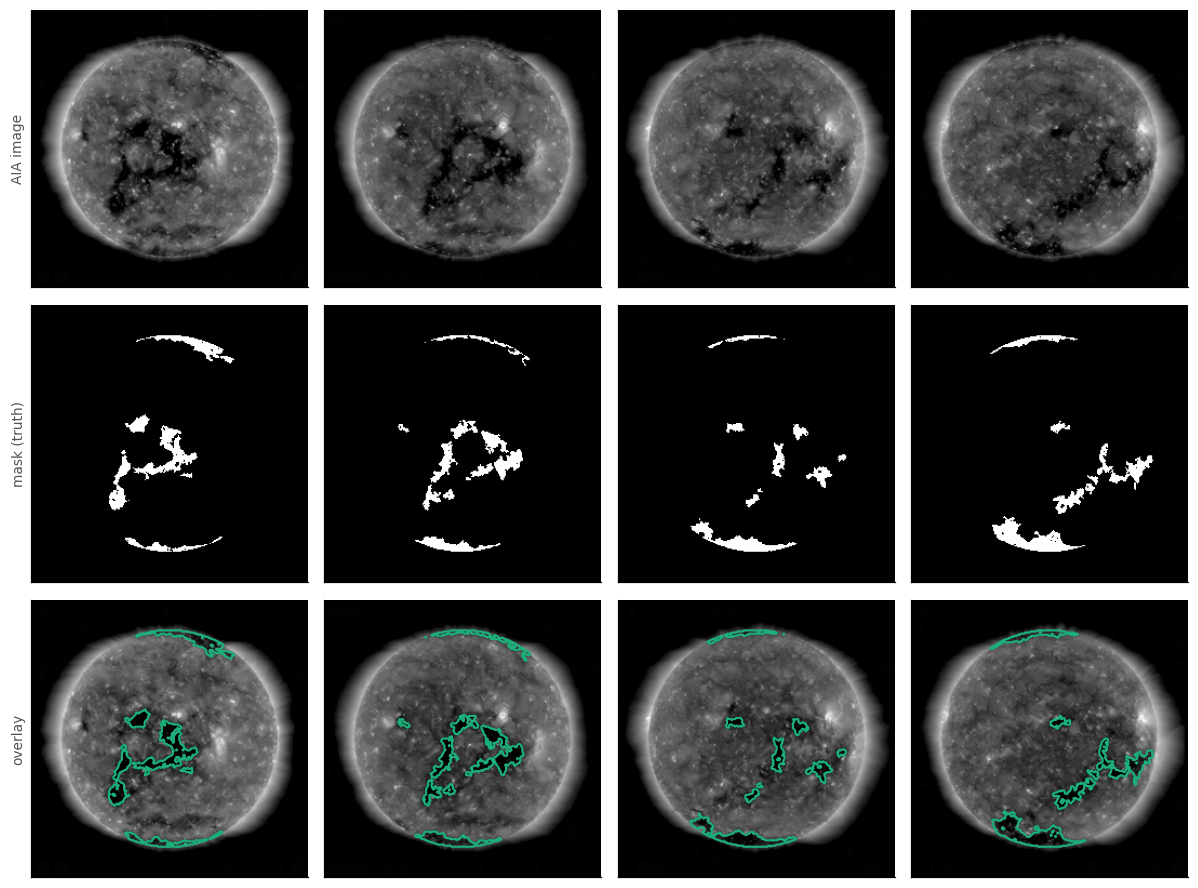

Average hole coverage: 3.2% of the image. That imbalance is why we use Dice/IoU, not accuracy.


In [12]:
# The data: input, reference mask, overlay.
fig, axes = plt.subplots(3, 4, figsize=(11, 8.2))
for col in range(4):
    p_img, p_msk = pairs[col * 5]
    img = np.asarray(Image.open(p_img).convert("L"), dtype=np.float32) / 255.0
    msk = load_mask_wh(p_msk, (SIZE, SIZE))
    axes[0, col].imshow(img, cmap="gray")
    axes[1, col].imshow(msk, cmap="gray")
    axes[2, col].imshow(img, cmap="gray")
    axes[2, col].contour(msk, levels=[0.5], colors=[C_FPGA], linewidths=1.4)
for row, label in enumerate(["AIA image", "mask (truth)", "overlay"]):
    axes[row, 0].set_ylabel(label, fontsize=9, color=C_INK)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.tight_layout(); plt.show()

cover = [load_mask_wh(m, (SIZE, SIZE)).mean() * 100 for _, m in pairs]
print(f"Average hole coverage: {np.mean(cover):.1f}% of the image. That imbalance is why we use Dice/IoU, not accuracy.")

### The Floating-Point Baseline

Before we change anything, we need a reference to measure against. That reference is the original float Keras model, the neural network exactly as it was trained. We run it on one image end to end and record its Dice and IoU.

This is our accuracy baseline. Every version after this holds the *same* trained weights, so any change we see later comes from precision or the graph, not from the model having learned something different.

Parameters : 31,305
In -> Out  : (None, 256, 256, 1) -> (None, 256, 256, 1)


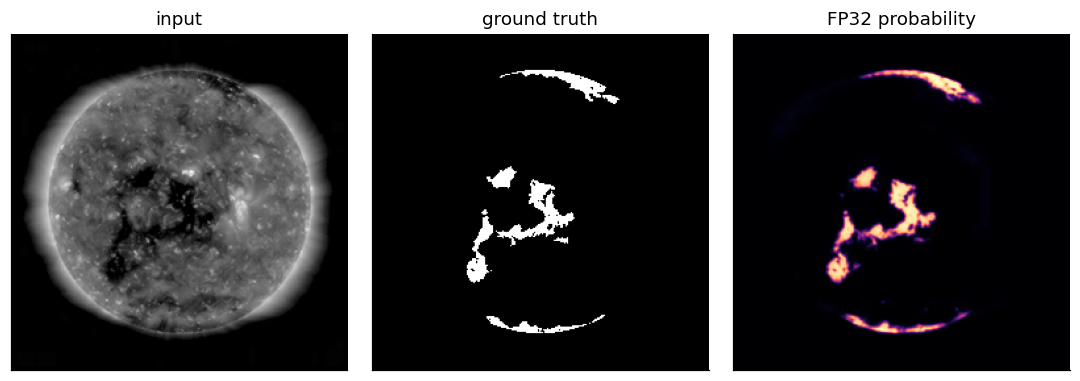

float baseline: Dice 0.8781  IoU 0.7827


In [13]:
def load_keras_h5(path):
    try:
        return tf.keras.models.load_model(path, compile=False)
    except Exception as e1:
        print("tf.keras failed:", type(e1).__name__, "- trying tf_keras")
        try:
            import tf_keras
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tf-keras"], check=True)
            import tf_keras
        return tf_keras.models.load_model(path, compile=False)

keras_model = load_keras_h5(H5)
print("Parameters :", f"{keras_model.count_params():,}")
print("In -> Out  :", keras_model.input_shape, "->", keras_model.output_shape)

# One image end to end - the sigmoid probability map, then a 0.5 threshold.
img_p, msk_p = pairs[0]
x_nhwc = load_image_nhwc(img_p, (SIZE, SIZE))
gt     = load_mask_wh(msk_p, (SIZE, SIZE))
prob_keras = keras_model.predict(x_nhwc, verbose=0)[0, :, :, 0]
pred_keras = (prob_keras > THRESHOLD).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(x_nhwc[0, :, :, 0], cmap="gray")
axes[0].set_title("input")

axes[1].imshow(gt, cmap="gray")
axes[1].set_title("ground truth")

axes[2].imshow(prob_keras, cmap="magma", vmin=0, vmax=1)
axes[2].set_title("FP32 probability")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.tight_layout(); plt.show()
print(f"float baseline: Dice {dice_score(gt, pred_keras):.4f}  IoU {iou_score(gt, pred_keras):.4f}")

## 2️⃣ First Try: It Doesn't Fit

Okay, you probably already suspect that we need to prepare the model a little before we can actually deploy it to the FPGA simulator. But just to *see* how deployment works (and what goes wrong), let's take the model we just explored and try to push it onto the chip as-is, and watch what happens.

For the deployment we use the `vbx_tool` helper we defined back in Section 0. It runs an SDK command-line tool — here `vnnx_compile`, the compiler that turns a model into a `.vnnx` binary for the accelerator, inside the SDK's own virtual environment, and hands us back whatever it printed. This is the same helper we'll use for every compile from here on.

There's one catch worth knowing about. Because of the Colab environment, the compiler is noisy and unreliable about its exit code: it prints walls of banners and will often report "success" (exit 0) even when it quietly refused to build anything. So instead of trusting the exit code, we use a small helper, `produced_vnnx`, which checks the only thing that actually matters — whether a real `.vnnx` file was written to disk.

The call passes a few command-line options straight through to `vnnx_compile`. Here's what each one means:

- **`-s V1000`** sets the target core size. VectorBlox comes in a few sizes (`V250`, `V500`, `V1000`), and each has a different number of compute lanes and scratchpad memory. Bigger cores are faster but use more of the FPGA's area and power. We start with the largest, `V1000`, and compare the sizes later in Section 6d.
- **`-c ncomp`** picks the compression mode for the model's weights. `ncomp` means "no compression", the simplest option, which keeps this first run easy to reason about.
- **`-t <model>`** is the input model to compile (the `.tflite` file).
- **`-o <name>`** is the output filename for the compiled `.vnnx` binary.

So `vbx_tool("vnnx_compile", "-s", "V1000", "-c", "ncomp", "-t", TFL_FP32, "-o", "fp32.vnnx")` reads as: compile the float model for a V1000 core, no weight compression, and write the result to `fp32.vnnx`.

In [14]:
FAIL = WORK / "build_fp32"
FAIL.mkdir(exist_ok=True)
out_vnnx = FAIL / "fp32.vnnx"
if out_vnnx.exists():
    out_vnnx.unlink()
rc, out = vbx_tool("vnnx_compile", "-s", "V1000", "-c", "ncomp",
                   "-t", TFL_FP32, "-o", "fp32.vnnx", cwd=FAIL, echo=False)

if produced_vnnx(out_vnnx):
    print("Got a .vnnx (did not expect that).")
else:
    print("No .vnnx came out. The chip won't take the float model, which is the whole point.\n")
print("what the compiler actually said (banners stripped):")
print(clean_log(out, 8))

No .vnnx came out. The chip won't take the float model, which is the whole point.

what the compiler actually said (banners stripped):
FLOAT32 inputs not supported (for operator 0 CONV_2D)


## 3️⃣ Fix: Quantize to INT8

The first wall we hit was the numbers. The VectorBlox core is integer-only: there is no floating-point path in the hardware, so a float model simply can't run on it. The fix is **quantization**, converting the model from 32-bit floats to 8-bit integers (INT8).

The idea is to store each number as a small integer plus a scale factor, so that:

```
real_value ≈ scale * (quantized_int - zero_point)
```


Instead of keeping a full 32-bit float per weight and activation, we keep an 8-bit integer (values from -128 to 127) and a couple of extra numbers per tensor that say how to map those 256 steps back onto the real range. The whole trick is putting those 256 steps where the values actually are: too wide a range wastes precision, too narrow and you clip the extremes.

How are those scales chosen? For the weights it's easy, since their range is fixed once training is done. For the activations it depends on the input, so the model is **calibrated**: a handful of representative images are run through the float model and the ranges that show up are measured. No retraining and no labels are needed, just a few sample images. (This flavour, done after training, is called post-training quantization; the full story is in Appendix A1.)

Why bother? INT8 multiply-add is far cheaper in silicon, power, and memory than float, which is exactly what a satellite's tight power and memory budget cares about. It's also why essentially every edge AI accelerator works this way.

The package already ships the quantized file, so here we just look at it and try the compile again. Notice how the input and output dtypes change from `float32` to `int8`, and how much smaller the file is on disk.

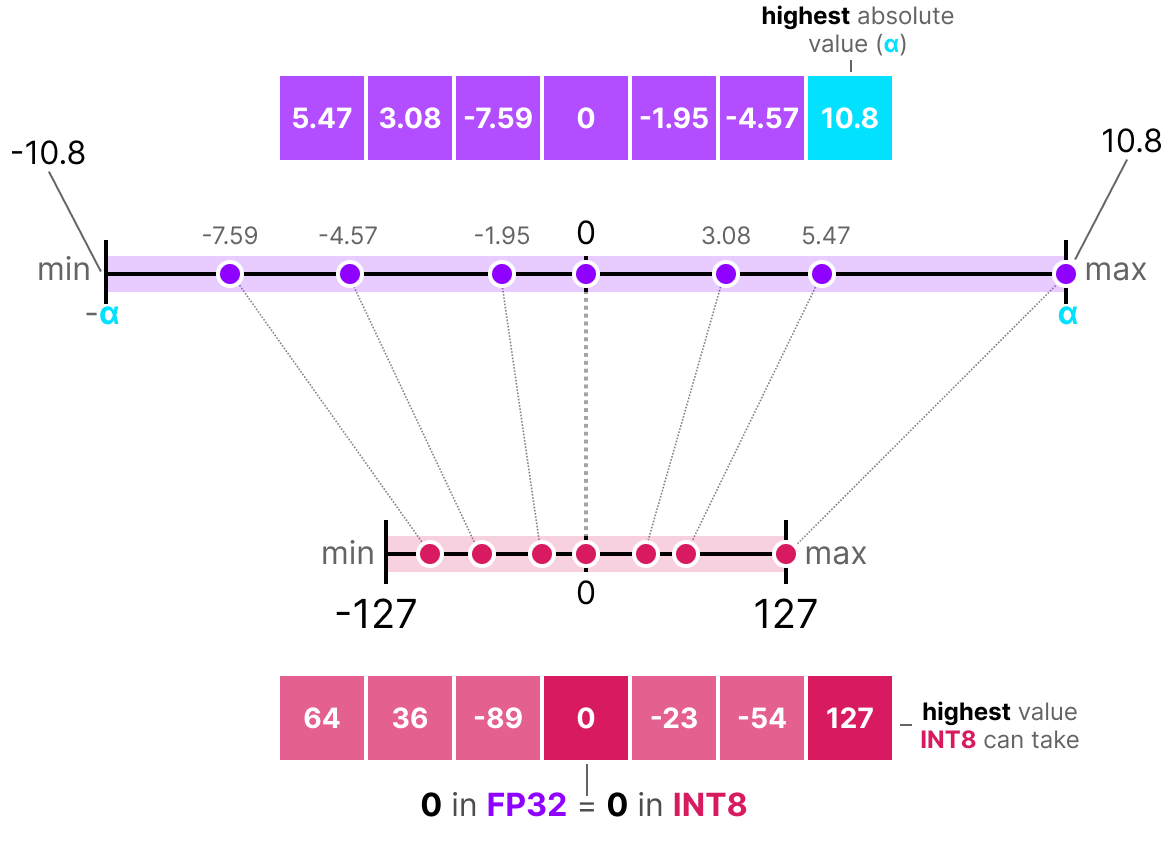

📝 Task:

- [ ] For more information about quantization check out: https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-quantization$0

### Inspecting the Quantized File

The package already ships the quantized model, so before we try compiling it, let's just look at it. The cell below opens both the original float TFLite file and the INT8 one and prints their input/output data types side by side. The thing to notice: the INT8 model's input and output are now `int8` rather than `float32` — the numbers have changed type. It is also noticeably smaller on disk, which is the first hint of why integer models are attractive for a memory-limited target.


> If you wan to see the comparison of the FP32 vs INT8 model, jump to seciton [6a](https://colab.research.google.com/drive/1AsZU75KTQsedRdfk3mrvjPDXR2TdJYS1#scrollTo=iACrhGemAWng)

In [15]:
# The quantized file. Inputs and outputs are int8 now, each with a (scale, zero_point).
for p in [TFL_FP32, TFL_INT8]:
    itp = tf.lite.Interpreter(model_path=str(p));
    itp.allocate_tensors()
    di, do = itp.get_input_details()[0], itp.get_output_details()[0]
    print(f"{p.name:26} {p.stat().st_size:>7,} B  "
          f"in={np.dtype(di['dtype']).name}  out={np.dtype(do['dtype']).name}")
print(f"\nThe int8 file is {H5.stat().st_size / TFL_INT8.stat().st_size:.1f}x smaller than the .h5.")

model-4-3-fp32.tflite      151,272 B  in=float32  out=float32
model-4-3-int8.tflite       66,336 B  in=int8  out=int8

The int8 file is 9.2x smaller than the .h5.


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Compiling the INT8 Model

Now we tryu to compile the INT8 version model for the VectorBlox.

In [16]:
# Try the compile again on the int8 model. The numbers are sorted now; the question is the ops.
PLAIN = WORK / "build_int8_plain"; PLAIN.mkdir(exist_ok=True)
out_vnnx = PLAIN / "int8_plain.vnnx"
if out_vnnx.exists():
    out_vnnx.unlink()
rc, out = vbx_tool("vnnx_compile", "-s", "V1000", "-c", "ncomp",
                   "-t", TFL_INT8, "-o", "int8_plain.vnnx", cwd=PLAIN, echo=False)

if produced_vnnx(out_vnnx):
    print("Got a .vnnx, so this SDK already handles the graph as-is.")
    print("   Section 4 shows why the package still rewrites it anyway.")
else:
    print("No .vnnx. Some op or shape still isn't hardware-legal. Section 4 fixes that.")
print("\nwhat the compiler said (banners stripped):")
print(clean_log(out, 10))

No .vnnx. Some op or shape still isn't hardware-legal. Section 4 fixes that.

what the compiler said (banners stripped):
    optimized_tflite = save_graph(args.tflite.replace('.tflite', '.tr.tflite'), dir_obj, optimized_graph, copy=args.debug)
  File "/content/VectorBlox-SDK/python/vbx/vbx/generate/transform_tflite.py", line 2576, in save_graph
    update_shapes(tname, graph)
  File "/content/VectorBlox-SDK/python/vbx/vbx/generate/transform_tflite.py", line 101, in update_shapes
    details = get_tensor_details(tflite_path)
  File "/content/VectorBlox-SDK/python/vbx/vbx/generate/transform_tflite.py", line 91, in get_tensor_details
    interpreter.allocate_tensors()
  File "/content/VectorBlox-SDK/vbx_env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py", line 531, in allocate_tensors
    return self._interpreter.AllocateTensors()
RuntimeError: tensorflow/lite/kernels/split.cc Not an even splitNode number 29 (SPLIT) failed to prepare.


## 4️⃣ Fix: Rewrite the Graph

Okay so quantization sorted out the numbers, but it didn't really touch the shape of the network, and that's the second problem. The plain INT8 model is still made of operations and shapes the hardware just can't run, so the compile gives up before it finishes.

The thing is, since we're running on the VectorBlox soft core, we can only use the operations the core actually knows. And a lot of the ops in a normal exported model aren't even doing math, they're just there to shuffle tensor shapes around while the model runs (stuff like `SHAPE`, `RESHAPE`, `STRIDED_SLICE`, `TILE`, `EXPAND_DIMS`, `PACK`). The core can't handle that kind of dynamic shape juggling, so as soon as it sees something it doesn't support, the compile stops.

So what we usually need to do is change some of these graph operations into something the core can actually take. Good news is we don't have to do this by hand, there are various post-training "surgery" tools that grab a standard INT8 TFLite file and rewrite it into a hardware friendly one. They keep the same trained weights, swap the unsupported ops for ones that work, and pin all the shapes so the compiler knows every size up front. What comes out is still a normal `.tflite` file, just reshaped into something the core is happy with.

And just like with the quantized model, we already have a fixed version sitting in the package, so we don't have to run the surgery ourselves this time. We'll just load it, take a look at what actually changed op by op, and then compile the one that works.

You can see the effect right in the table below: all the shape-juggling ops drop to zero, `TRANSPOSE_CONV` is gone, and instead we get a few more plain `CONV_2D` layers and a static `RESIZE_NEAREST_NEIGHBOR` doing the upsampling. Same network, same weights, just written in operations the core supports.

### Seeing What the Rewrite Changed

Here we've got a small util that lists the ops in both models and compares them side by side, so you can see exactly what the surgery did. It reaches into a private TFLite API to pull the op names (with a fallback so it doesn't break on newer TensorFlow versions), then just counts them and flags whatever moved.

In [17]:
def tflite_ops(path):
    """Return the list of operator names used in a .tflite model.

    TFLite has no public API for this, so we use the private _get_ops_details()
    and fall back to a placeholder if a future TF version renames it.
    """
    itp = tf.lite.Interpreter(model_path=str(path))
    itp.allocate_tensors()
    try:
        return [o["op_name"] for o in itp._get_ops_details()]
    except AttributeError:
        return ["<op list unavailable in this TF version>"]


In [18]:
# What the rewrite changed, op by op.
from collections import Counter
before, after = Counter(tflite_ops(TFL_INT8)), Counter(tflite_ops(TFL_VBX))
print(f"{'operation':22}{'plain':>7}{'vbx':>6}")
print("-" * 35)
for k in sorted(set(before) | set(after)):
    b_, a_ = before.get(k, 0), after.get(k, 0)
    flag = "" if b_ == a_ else "  <- changed"
    print(f"{k:22}{b_:>7}{a_:>6}{flag}")

operation               plain   vbx
-----------------------------------
CONCATENATION               9     3  <- changed
CONV_2D                     9    15  <- changed
DELEGATE                    5     4  <- changed
EXPAND_DIMS                 6     0  <- changed
LOGISTIC                    1     1
MAX_POOL_2D                 3     3
PACK                        3     0  <- changed
RESHAPE                     6     0  <- changed
RESIZE_NEAREST_NEIGHBOR      0     3  <- changed
SHAPE                      12     0  <- changed
STRIDED_SLICE               9     0  <- changed
TILE                        6     0  <- changed
TRANSPOSE_CONV              6     0  <- changed


### Building the `.vnnx`

Now we've got both fixes in place, the INT8 quantization and the graph rewrite, so let's try compiling the model again. This time it should actually go through and give us a `.vnnx`, the same file you'd copy onto a real PolarFire board.

In [19]:
# Compile the rewritten graph. This writes the .vnnx (and a .hex, via objcopy).
BUILD = WORK / "build_vnnx"; BUILD.mkdir(exist_ok=True)
t0 = time.perf_counter()
rc, out = vbx_tool("vnnx_compile", "-s", "V1000", "-c", "ncomp",
                   "-t", TFL_VBX, "-o", "model-4-3_V1000_ncomp.vnnx", cwd=BUILD, echo=False)
if rc != 0:
    print(out[-2000:]); raise RuntimeError(f"vnnx_compile failed (rc={rc})")
VNNX = BUILD / "model-4-3_V1000_ncomp.vnnx"
print(f"compiled in {time.perf_counter()-t0:.0f} s  ->  {VNNX.name}  ({VNNX.stat().st_size:,} B)")

compiled in 12 s  ->  model-4-3_V1000_ncomp.vnnx  (397,224 B)


## 5️⃣ Run It and Look Inside

Now we switch from building the model to actually running it. We'll load our compiled `.vnnx` into the simulator, run the test vector baked into the file as a quick sanity check, and then push one of our own images through and look at the mask.

This also means we finally need the VectorBlox-side helpers we skipped earlier:
- `load_image_nchw` for loading images in the layout the hardware wants, and
- `vnnx_quantize` / `vnnx_dequantize` to convert images into the INT8 values the accelerator takes and turn its output back into probabilities. We import them here, right where the FPGA path begins.

In [20]:
from analyze_vnnx_simulation import (
    load_image as load_image_nchw,   # NCHW layout, for VectorBlox
    quantize   as vnnx_quantize,
    dequantize as vnnx_dequantize,
)


### (Optional) Loading the Model and Running Its Baked-In Test Vector

Every `.vnnx` carries a reference input/output pair inside it. Loading the model and running that baked-in test vector is a fast integrity check: if our freshly compiled binary reproduces the expected output, the whole toolchain is behaving. A difference of `0` is a perfect match; a small difference is usually just our locally compiled file differing slightly from the packaged one, while a large difference would mean something is genuinely wrong.


In [22]:
# Load it in the simulator and run the test vector baked into the file (ideally matches exactly).
from vbx.sim.model import Fletcher32
with open(VNNX, "rb") as f:
    sim_model = vbx.sim.Model(f.read())
_, _, H, W = sim_model.input_shape[0]
print("core           :", sim_model.model_size_conf.name)
print("input shape    :", sim_model.input_shape[0], "(NCHW)")

out_ref = sim_model.run(sim_model.test_input)
max_dev = max(int(np.abs(a.astype(int) - b.astype(int)).max())
              for a, b in zip(out_ref, sim_model.test_output))
print(f"test vector, biggest difference: {max_dev}   (0 would be an exact match)")

core           : V1000
input shape    : [1, 1, 256, 256] (NCHW)
test vector, biggest difference: 10   (0 would be an exact match)


### Running One of Our Own Images

The test vector proves the pipeline works; now let's use it for real. The `vnnx_predict` helper below runs the full inference path exactly as it would on the chip: load the image in NCHW, quantize it to INT8, run it through the accelerator, dequantize the result back to probabilities, and threshold to a mask. We then score that mask against the ground truth with the same Dice/IoU we've used all along — so this number is directly comparable to the float baseline from Section 1.

(The cell also prints a wall-clock time. Ignore it as a speed figure for now — it is how long our CPU took to *simulate* the chip, not the chip's own speed. We untangle the different notions of "time" in Section 6b.)


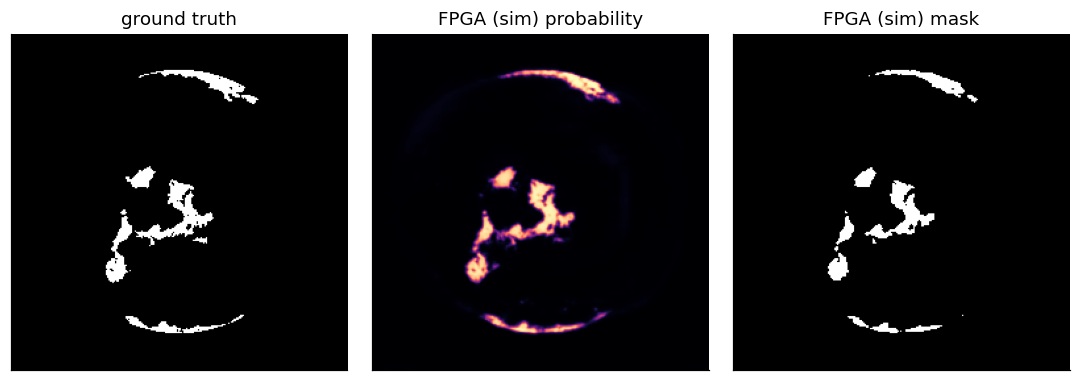

FPGA (sim)  Dice 0.8701   IoU 0.7702
simulator wall-clock: 1304 ms   (this is NOT the chip's speed, see 6b)


In [23]:
# Our own image through the accelerator: quantize -> run -> dequantize -> threshold.
def vnnx_predict(model, image_path):
    x = load_image_nchw(image_path, H, W)
    xq = vnnx_quantize(x, model.input_scale_factor[0],
                       model.input_zeropoint[0], model.input_dtypes[0])
    t0 = time.perf_counter()
    raw = model.run([xq.flatten()])
    wall_ms = (time.perf_counter() - t0) * 1000.0
    prob = vnnx_dequantize(raw[0], model.output_shape[0],
                           model.output_scale_factor[0], model.output_zeropoint[0])
    return prob[0, 0], wall_ms

prob_vnnx, wall_ms = vnnx_predict(sim_model, img_p)
pred_vnnx = (prob_vnnx > THRESHOLD).astype(np.uint8)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(gt, cmap="gray")
axes[0].set_title("ground truth")

axes[1].imshow(prob_vnnx, cmap="magma", vmin=0, vmax=1)
axes[1].set_title("FPGA (sim) probability")

axes[2].imshow(pred_vnnx, cmap="gray")
axes[2].set_title("FPGA (sim) mask")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.tight_layout(); plt.show()
print(f"FPGA (sim)  Dice {dice_score(gt, pred_vnnx):.4f}   IoU {iou_score(gt, pred_vnnx):.4f}")
print(f"simulator wall-clock: {wall_ms:.0f} ms   (this is NOT the chip's speed, see 6b)")

## 6️⃣ Checks and comparisons


### 6a. What Did Quantization Actually Cost?

Same image, same weights, float vs int8. The thing to watch is the third panel: the
probabilities shift a little everywhere, but that only matters where it pushes a pixel
across the 0.5 line, and that basically only happens on the edge of the hole.

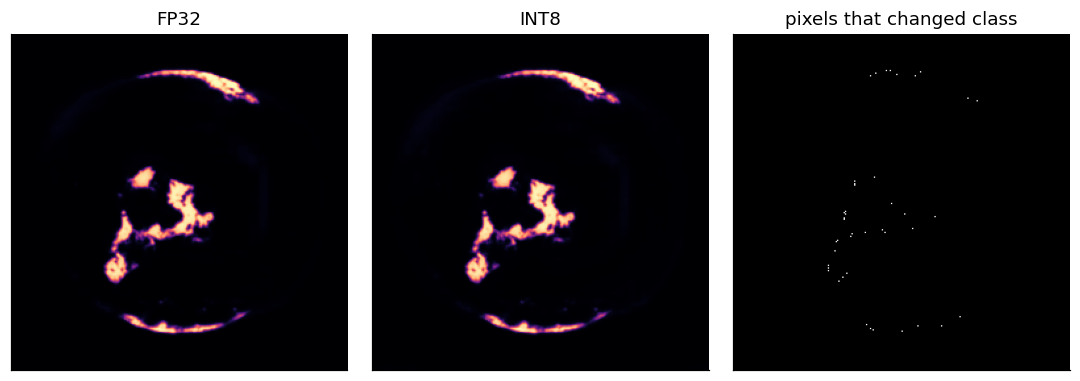

pixels changed: 43 of 65536 (0.07%)
Dice  FP32 0.8781  ->  INT8 0.8721


In [24]:
from analyze_model import quantize_input, dequantize_output

itp_vbx = tf.lite.Interpreter(model_path=str(TFL_VBX)); itp_vbx.allocate_tensors()
in_d, out_d = itp_vbx.get_input_details()[0], itp_vbx.get_output_details()[0]

def tflite_predict(itp, in_d, out_d, x):
    itp.set_tensor(in_d["index"], quantize_input(x, in_d)); itp.invoke()
    return dequantize_output(itp.get_tensor(out_d["index"]), out_d)[0, :, :, 0]

prob_int8 = tflite_predict(itp_vbx, in_d, out_d, x_nhwc)
pred_int8 = (prob_int8 > THRESHOLD).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(prob_keras, cmap="magma", vmin=0, vmax=1)
axes[0].set_title("FP32")

axes[1].imshow(prob_int8,  cmap="magma", vmin=0, vmax=1)
axes[1].set_title("INT8")

axes[2].imshow(pred_keras ^ pred_int8, cmap="gray")
axes[2].set_title("pixels that changed class")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.tight_layout(); plt.show()
diff_px = int((pred_keras ^ pred_int8).sum())
print(f"pixels changed: {diff_px} of {SIZE*SIZE} ({100*diff_px/SIZE**2:.2f}%)")
print(f"Dice  FP32 {dice_score(gt, pred_keras):.4f}  ->  INT8 {dice_score(gt, pred_int8):.4f}")

### 6b. Three Different "Times", and Which One to Believe

We run all 20 images and compare four latency numbers, and the point is that not all of them mean the same thing. The simulator wall-clock is the tempting one to look at, but it's basically useless as a speed: it's just how long our CPU took to *pretend* to be the chip, stepping through every hardware instruction in software. It says nothing about how fast the real board would be.

The number that actually matters is **cycles times clock**. The simulator gives us an exact cycle count for our compiled model (via `get_estimated_runtime()`), and that count is a real hardware property, it won't change no matter what machine we run the simulator on. To turn cycles into a time, we just divide by the clock frequency the core runs at on the FPGA:

```
latency = cycles / clock_frequency
```


So what clock does it actually run at? On the PolarFire SoC Video Kit (the board VectorBlox targets), the FPGA fabric runs its vision pipeline at around 150 MHz. In the notebook we use 100 MHz instead, on purpose, as a safe, round, conservative floor: if the model is fast enough at 100 MHz, it's only going to be faster on real silicon.

Our model comes out around 283k cycles, so:

- **at 100 MHz** (our conservative estimate): 283,000 / 100,000,000 ≈ **2.83 ms** per inference, or about 350 inferences per second
- **at 150 MHz** (closer to the real board): 283,000 / 150,000,000 ≈ **1.89 ms** per inference, or about 530 inferences per second

Either way it's a couple of milliseconds, which is plenty for something like a coronal-hole mask that you might compute once a minute on orbit. And notice the nice property here: because we kept cycles and clock separate, the same cycle count ports straight to any board, you just plug in that board's clock.


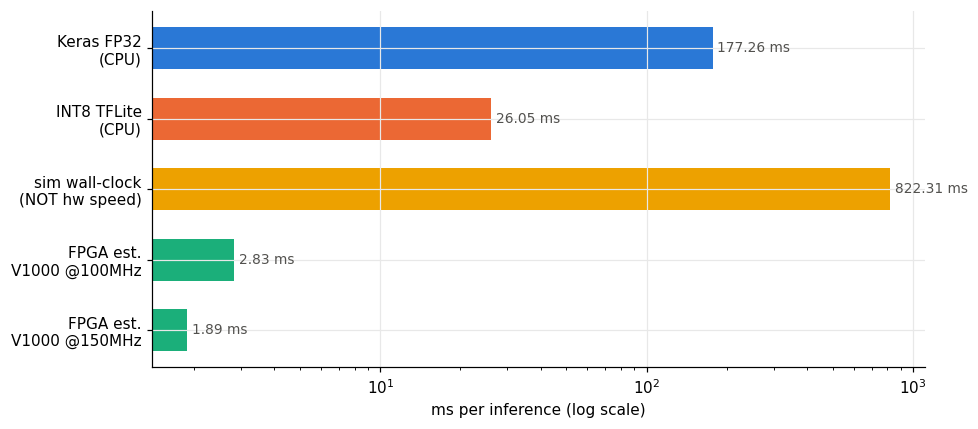

Model cycle count      : 282,907 cycles
FPGA estimate @100 MHz : 2.83 ms  (353 inferences/s)
FPGA estimate @150 MHz : 1.89 ms  (530 inferences/s)
FPGA vs INT8-CPU       : 9.2x faster (at 100 MHz)
Simulator vs CPU       : 32x SLOWER than CPU (expected, it's emulating hardware)


In [25]:
def run_one(image_path, mask_path):
    """Run all three backends on a single image. Returns a dict of (mask, latency_ms) per backend."""
    gt_mask = load_mask_wh(mask_path, (SIZE, SIZE))
    x = load_image_nhwc(image_path, (SIZE, SIZE))

    # Keras FP32 on CPU
    t0 = time.perf_counter()
    prob_k = keras_model.predict(x, verbose=0)[0, :, :, 0]
    ms_k = (time.perf_counter() - t0) * 1000

    # INT8 TFLite on CPU
    t0 = time.perf_counter()
    prob_i = tflite_predict(itp_vbx, in_d, out_d, x)
    ms_i = (time.perf_counter() - t0) * 1000

    # VectorBlox simulator
    prob_v, ms_v = vnnx_predict(sim_model, image_path)

    return {
        "gt":    gt_mask,
        "keras": ((prob_k > THRESHOLD).astype(np.uint8), ms_k),
        "int8":  ((prob_i > THRESHOLD).astype(np.uint8), ms_i),
        "sim":   ((prob_v > THRESHOLD).astype(np.uint8), ms_v),
    }


# Run every image through all three backends.
results = [run_one(ip, mp) for ip, mp in pairs]

# Average wall-clock latency for each CPU/simulator backend (milliseconds).
ms_keras = np.mean([r["keras"][1] for r in results])
ms_int8  = np.mean([r["int8"][1]  for r in results])
ms_sim   = np.mean([r["sim"][1]   for r in results])

# FPGA latency is NOT measured, it is computed from the cycle count and the clock.
cycles = sim_model.get_estimated_runtime()
ms_fpga_100 = cycles / 100e6 * 1000   # conservative floor
ms_fpga_150 = cycles / 150e6 * 1000   # closer to the real PolarFire board

# Plot the latency numbers side by side (log scale, since they span orders of magnitude).
labels = [
    "Keras FP32\n(CPU)",
    "INT8 TFLite\n(CPU)",
    "sim wall-clock\n(NOT hw speed)",
    "FPGA est.\nV1000 @100MHz",
    "FPGA est.\nV1000 @150MHz",
]
values = [ms_keras, ms_int8, ms_sim, ms_fpga_100, ms_fpga_150]
colors = [C_FP32, C_INT8, C_SIM, C_FPGA, C_FPGA]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values, color=colors, height=0.6)
ax.set_xscale("log")
ax.set_xlabel("ms per inference (log scale)")
ax.invert_yaxis()
bar_labels(ax, bars, fmt="{:.2f} ms", horizontal=True)
fig.tight_layout()
plt.show()

print(f"Model cycle count      : {cycles:,} cycles")
print(f"FPGA estimate @100 MHz : {ms_fpga_100:.2f} ms  ({1000/ms_fpga_100:.0f} inferences/s)")
print(f"FPGA estimate @150 MHz : {ms_fpga_150:.2f} ms  ({1000/ms_fpga_150:.0f} inferences/s)")
print(f"FPGA vs INT8-CPU       : {ms_int8/ms_fpga_100:.1f}x faster (at 100 MHz)")
print(f"Simulator vs CPU       : {ms_sim/ms_int8:.0f}x SLOWER than CPU (expected, it's emulating hardware)")

### 6c. Compute-Bound or Memory-Bound?

Okay so we know how long the model takes now, but if we wanted to make it faster, what would we even change? That's what this cell is about. Running the model is really two jobs happening at the same time: the actual math (compute), and shuffling data in and out of memory (DMA). Because they run in parallel, the time isn't the two added together, it's whichever one is slower, `max(dma_cycles, instruction_cycles)`. The faster job just hides behind the slower one.

So the slower of the two is our bottleneck, and that tells us where to spend effort. If we're compute-bound, a bigger core with more lanes helps. If we're memory-bound, more compute lanes just sit there waiting for data, and what actually helps is moving less of it (compressing weights, or shrinking those big feature maps). The cell below prints both numbers so we can see which side we're on.


In [26]:
prob_x, _ = vnnx_predict(sim_model, img_p)
st = sim_model.stats
LOG_LANES = (2, 3, 3, 4, 4)
log_lanes = LOG_LANES[preset_select["PRESET"][sim_model.model_size_conf.name]]
instr_cycles = sum(sum(c) for c in st.instruction_cycles)
dma_cycles = st.dma_cycles[log_lanes]
print(f"compute cycles : {instr_cycles:>12,}")
print(f"DMA cycles     : {dma_cycles:>12,}")
verdict = "memory-bound (DMA wins)" if dma_cycles > instr_cycles else "compute-bound (compute wins)"
print(f"-> {verdict}")
print(f"\nDMA bytes moved: {st.dma_bytes:>12,}  ({st.dma_bytes/2**20:.1f} MB)")
print(f"model on disk  : {VNNX.stat().st_size:>12,}  -> {st.dma_bytes/VNNX.stat().st_size:.0f}x more data moved than the model weighs")

compute cycles :      282,907
DMA cycles     :      193,539
-> compute-bound (compute wins)

DMA bytes moved:    6,184,756  (5.9 MB)
model on disk  :      397,224  -> 16x more data moved than the model weighs


So on the V1000 this model is **compute-bound**, but only just: 283k compute cycles versus 194k DMA cycles. Compute is the bottleneck, so a bigger core with more lanes would help here, and there's headroom, because while the math runs, the DMA has already finished fetching and is sitting idle for a good chunk of the time.

But look at the data number, because that's the more interesting part. The model is only about 0.4 MB on disk, yet running it moves almost 6 MB around, roughly 16x its own weight. That's the U-Net showing its true colors: those big full-size feature maps and skip connections have to be shuffled in and

### 6d. V250 vs V500 vs V1000

So far we've only used the biggest core, the V1000. But VectorBlox comes in a few sizes, and picking one is a real design decision: a smaller core takes up less of the FPGA and burns less power, which on a satellite matters a lot, but it's also slower. This cell compiles the same model for all three sizes and lines them up so we can see the tradeoff.

Worth guessing before you run it. The accuracy should be identical across all three, since it's the same weights doing the same math, the core size only changes how fast the work gets done, not the result. And smaller cores should need more cycles. The interesting bit is the bottleneck column: remember from 6c that our model was compute-bound on the V1000, but sits close to the edge. As we shrink the core (and its scratchpad), it has to move data around more, so watch whether it tips over into memory-bound. Give it about 5 minutes for the three compiles.

In [27]:
import gc

CORES = ["V250", "V500", "V1000"]
LOG_LANES = (2, 3, 3, 4, 4)

# Compile the same model for each core size (skips any that already exist).
for core in CORES:
    name = f"model-4-3_{core}_ncomp.vnnx"
    if not (BUILD / name).exists():
        rc, out = vbx_tool("vnnx_compile", "-s", core, "-c", "ncomp",
                           "-t", TFL_VBX, "-o", name, cwd=BUILD, echo=False)
        if rc != 0:
            print(f"{core}: compile failed")
            continue
    print(f"{core}: ready")

# The simulator is a single shared instance, so free the current model before loading others.
try:
    del sim_model
except NameError:
    pass
gc.collect()

# For each core: run a few images for accuracy, and read cycles + the compute/DMA split.
rows = {}
for core in CORES:
    path = BUILD / f"model-4-3_{core}_ncomp.vnnx"
    if not path.exists():
        continue

    with open(path, "rb") as f:
        m = vbx.sim.Model(f.read())
    _, _, h, w = m.input_shape[0]

    dices = []
    for ip, mp in pairs[:5]:
        gtm = load_mask_wh(mp, (SIZE, SIZE))
        xq = vnnx_quantize(load_image_nchw(ip, h, w), m.input_scale_factor[0],
                           m.input_zeropoint[0], m.input_dtypes[0])
        raw = m.run([xq.flatten()])[0]
        pr = vnnx_dequantize(raw, m.output_shape[0],
                             m.output_scale_factor[0], m.output_zeropoint[0])[0, 0]
        dices.append(dice_score(gtm, (pr > THRESHOLD).astype(np.uint8)))

    # Compute vs DMA cycles, so we can see the bottleneck for this core.
    log_lanes = LOG_LANES[preset_select["PRESET"][m.model_size_conf.name]]
    instr_cycles = sum(sum(c) for c in m.stats.instruction_cycles)
    dma_cycles = m.stats.dma_cycles[log_lanes]
    bound = "memory" if dma_cycles > instr_cycles else "compute"

    rows[core] = {
        "cycles": m.get_estimated_runtime(),
        "dice": float(np.mean(dices)),
        "compute": instr_cycles,
        "dma": dma_cycles,
        "bound": bound,
    }

    del m
    gc.collect()

# Print the comparison.
print(f"{'core':7}{'cycles':>12}{'ms@100MHz':>11}{'compute':>12}{'DMA':>12}{'bottleneck':>12}{'Dice':>9}")
print("-" * 75)
for core, r in rows.items():
    print(f"{core:7}{r['cycles']:>12,}{r['cycles']/100e6*1000:>11.2f}"
          f"{r['compute']:>12,}{r['dma']:>12,}{r['bound']:>12}{r['dice']:>9.4f}")

V250: ready
V500: ready
V1000: ready
core         cycles  ms@100MHz     compute         DMA  bottleneck     Dice
---------------------------------------------------------------------------
V250      1,131,571      11.32   1,131,571     387,377     compute   0.8440
V500        565,849       5.66     565,849     194,252     compute   0.8440
V1000       282,907       2.83     282,907     193,539     compute   0.8440


---
# 📚 Appendix

## A1. (Optional) The HLS Approach

Everything up to now used the overlay route: one fixed VectorBlox core sits on the FPGA, and our model just runs on it as data. There's a completely different way to put a model on an FPGA though, and it's worth knowing it exists, the dataflow route with a tool like hls4ml.

The idea is that instead of running the model on a general-purpose core, you build a custom circuit for this one specific network, baked straight into the FPGA fabric. The flow has two parts:

1. **Python to C++ (we can do this part here).** hls4ml takes a Keras model and generates synthesizable HLS C++ describing the network. This only needs a C++ compiler, so it runs fine in Colab, and it even gives us a bit-accurate C-simulation to check the output still matches Keras.
2. **C++ to hardware (needs vendor software, done offline).** Turning that C++ into a real circuit (HDL, then place-and-route, then a bitstream) needs the FPGA vendor's synthesis tools. That's a heavy, offline step we can't run in Colab, so we'll show the command but not run it.

The reason you'd go through all this: since the circuit is custom-built for your one network instead of a general core that has to handle any model, it can be faster and smaller. You're not paying the overlay's one-size-fits-all overhead anymore.

The demo below uses the Vivado/Vitis backend, mostly so the C-simulation just works here. hls4ml also has other backends, and some of them might be a better fit for a PolarFire target, but we haven't had time to explore that further, so treat the choice of backend here as "whatever runs in Colab" rather than "what you'd ship on our board".

The usual dataflow downsides apply too: any change to the model means re-running the whole synthesis (place, route, timing, new bitstream), which is slow, it needs real FPGA tooling and know-how, and it fits small low-latency models far better than something like our 256x256 U-Net with skip connections and transpose convs. That's exactly why our model went the overlay route in the first place. So the two are a tradeoff: overlay is flexible and easy (model as data), dataflow is faster and leaner but rigid and much more work (model as a fixed circuit).

Below we run the part we can: generate the HLS C++ from a small model, check it against Keras, and show the `build()` command you'd run offline to get real hardware.

In [28]:
!pip install -q hls4ml 2>/dev/null
import numpy as np, tensorflow as tf, hls4ml

# A tiny dense model - small enough to transpile and C-simulate quickly.
m = tf.keras.Sequential([
    tf.keras.layers.Input((16,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(8,  activation="relu"),
    tf.keras.layers.Dense(1),
])
m.compile()

# Convert to an HLS project (generates synthesizable C++; no synthesis yet).
cfg = hls4ml.utils.config_from_keras_model(m, granularity="model")
hls_model = hls4ml.converters.convert_from_keras_model(
    m, hls_config=cfg, backend="Vitis", output_dir="/content/hls4ml_prj")
hls_model.compile()   # builds the bit-accurate C-simulation (needs only g++)

# Bit-accurate emulation vs Keras on random input.
x = np.random.rand(4, 16).astype(np.float32)
print("Keras :", m.predict(x, verbose=0).ravel())
print("hls4ml:", np.asarray(hls_model.predict(x)).ravel())
print("\nGenerated HLS C++ lives in /content/hls4ml_prj/firmware/")
print("To get real RTL + resource/latency (offline, needs Vivado/Vitis):")
print("    hls_model.build(csim=False, synth=True)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 22.5 MB/s eta 0:00:00
Keras : [-0.90518266 -0.7150237  -0.6207686  -0.47433025]
hls4ml: [-0.8652344  -0.6796875  -0.58496094 -0.453125  ]

Generated HLS C++ lives in /content/hls4ml_prj/firmware/
To get real RTL + resource/latency (offline, needs Vivado/Vitis):
    hls_model.build(csim=False, synth=True)


In [29]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True)

# 📝 Home Exercise: Quantize the Model Yourself

So far the INT8 model was handed to us in the package. For home, let's actually make it, because quantization is the one step that really matters for getting onto the chip.

- [ ] **Read first.** Two guides worth going through before you touch code:
  - A visual, intuition-first guide to what quantization actually is: https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-quantization
  - A hands-on TFLite walkthrough that shows the actual converter code: https://medium.com/sclable/model-quantization-using-tensorflow-lite-2fe6a171a90d
- [ ] **Quantize the float model to INT8 yourself** using the standard TFLite converter. You already have everything you need: the float model (`H5`) and the sample images (`IMGS`) to calibrate on.
- [ ] **Compare your result to the shipped file.** Run your INT8 model on a few images and check its Dice against the `model-4-3-int8.tflite` that came in the package. Are they close? Should they be?
- [ ] **Experiment.** Try calibrating on just 1 image versus all 20, or on only bright versus only dark images. Does the calibration set change the accuracy? This is the whole game of quantization in one experiment.

<details>
<summary>💡 See solution</summary>

<br>

<details>
<summary>Are you sure you want to see the solution?</summary>

<br>

<details>
<summary>You learn way more by trying it yourself first...</summary>

<br>

<details>
<summary>Are you really really really sure?</summary>

<br>

<details>
<summary>As you wish</summary>

<br>

```python
# ---- Solution: quantize the float model to INT8 yourself ----

# Calibration: the converter runs these images through the float model to
# measure the real value ranges, so it knows where to put the 256 INT8 steps.
def representative_dataset():
    for image_path, _ in pairs[:20]:
        x = load_image_nhwc(image_path, (SIZE, SIZE)).astype(np.float32)
        yield [x]

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

my_int8_tflite = converter.convert()
my_path = WORK / "my-model-int8.tflite"
with open(my_path, "wb") as f:
    f.write(my_int8_tflite)
print(f"Wrote my own INT8 model: {my_path.stat().st_size:,} bytes")

# ---- Compare our model against the one shipped in the package ----
def eval_tflite(path, n=5):
    itp = tf.lite.Interpreter(model_path=str(path))
    itp.allocate_tensors()
    in_d, out_d = itp.get_input_details()[0], itp.get_output_details()[0]
    dices = []
    for ip, mp in pairs[:n]:
        gt = load_mask_wh(mp, (SIZE, SIZE))
        x = load_image_nhwc(ip, (SIZE, SIZE))
        prob = tflite_predict(itp, in_d, out_d, x)
        dices.append(dice_score(gt, (prob > THRESHOLD).astype(np.uint8)))
    return float(np.mean(dices))

print(f"My INT8 model    : Dice {eval_tflite(my_path):.4f}")
print(f"Shipped INT8 model: Dice {eval_tflite(TFL_INT8):.4f}")
```

</details>
</details>
</details>
</details>
</details>